# 02 · Backtest and report

An event-driven backtest with realistic execution, the lamport-exact ledger, where the money goes, how sensitive the result is to latency, and the generated report.

> **Real data instead of the synthetic market.** Replace the generation cell with
> ```python
> from pumpfun_hft.collectors.storage import ParquetEventStore
> from pumpfun_hft.backtester.replay import load_metadata
> events = ParquetEventStore(settings.paths.events_dir).read()
> metadata = load_metadata(settings.paths.metadata_dir / "tokens.parquet")
> ```
> after running `collect-history` (or `stream`) from the CLI.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, polars as pl, matplotlib.pyplot as plt
from pumpfun_hft.core.config import load_settings
from pumpfun_hft.collectors.synthetic import SyntheticMarket

pl.Config.set_tbl_rows(12); pl.Config.set_tbl_cols(14); pl.Config.set_fmt_str_lengths(40); pl.Config.set_tbl_width_chars(160)
BLUE, ORANGE, AQUA, YELLOW, RED, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e34948", "#898781"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.edgecolor": "#c3c2b7", "font.size": 9})


In [2]:
settings = load_settings(None, {"synthetic.duration_hours": 12})
data = SyntheticMarket(settings).generate()
events, metadata = data.events, data.metadata
from pumpfun_hft.backtester.engine import BacktestEngine
from pumpfun_hft.backtester.replay import DataSource
runs = {}
for name in ["momentum_ignition", "smart_money", "volume_breakout"]:
    runs[name] = BacktestEngine(settings, DataSource(frame=events), [name], metadata=metadata, seed=42, synthetic=True).run()
pl.DataFrame([{"strategy": k, **{m: r.metrics.get(m) for m in ("total_return", "n_trades", "win_rate", "profit_factor",
              "max_drawdown", "fill_rate", "avg_latency_ms")}} for k, r in runs.items()])

strategy,total_return,n_trades,win_rate,profit_factor,max_drawdown,fill_rate,avg_latency_ms
str,f64,i64,f64,f64,f64,f64,f64
"""momentum_ignition""",0.014603,76,0.368421,1.134214,0.030423,0.928962,768.894118
"""smart_money""",0.102553,137,0.474453,1.690876,0.019475,0.746114,668.559028
"""volume_breakout""",-0.038706,17,0.0,0.0,0.039372,0.971429,707.176471


`smart_money` profits here **by construction**: the generator plants informed wallets. The others lose after costs. Neither says anything about the live market.

## The ledger reconciles to the lamport
Final equity = initial capital + the PnL of every closed round trip − fees of failed transactions that never opened a position.

In [3]:
r = runs["momentum_ignition"]
lhs = r.metrics["final_equity_sol"]
rhs = r.initial_capital_sol + r.trades["pnl_sol"].sum() - r.metrics["unattributed_costs_sol"]
print(f"final equity {lhs:.9f} SOL  vs  capital + trade PnL - unattributed {rhs:.9f} SOL  → diff {abs(lhs - rhs) * 1e9:.0f} lamports")

final equity 10.146032387 SOL  vs  capital + trade PnL - unattributed 10.146032387 SOL  → diff 0 lamports


## Where the money goes

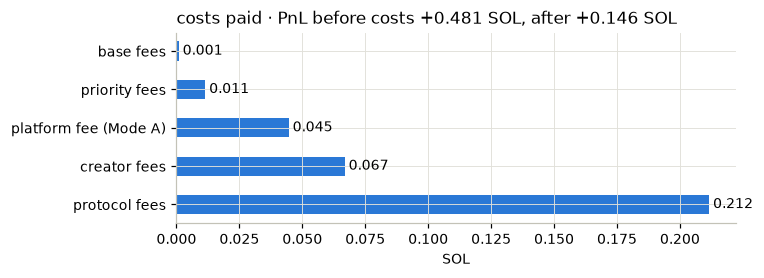

In [4]:
f = r.fills
costs = {k: float(f[c].sum()) / 1e9 for k, c in [("protocol fees", "protocol_fee"), ("creator fees", "creator_fee"),
         ("platform fee (Mode A)", "platform_fee"), ("priority fees", "priority_fee"), ("base fees", "network_fee")]}
gross = r.trades["pnl_sol"].sum() + sum(costs.values())
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(list(costs), list(costs.values()), color=BLUE, height=0.5)
for i, v in enumerate(costs.values()): ax.text(v, i, f" {v:.3f}", va="center")
ax.set_xlabel("SOL"); ax.set_title(f"costs paid · PnL before costs {gross:+.3f} SOL, after {r.metrics['pnl_sol']:+.3f} SOL", loc="left")
plt.tight_layout(); plt.show()

## Execution quality
Positive slippage is adverse (vs the quote at decision time). Buys during bursts land behind everyone who was faster.

In [5]:
from pumpfun_hft.analytics.report import ReportGenerator, exit_categories
display(ReportGenerator(r).execution_quality())
exit_categories(r.trades)

side,fills,avg_slip_bps,median_slip_bps,p90_slip_bps,slippage_sol,p50_latency_ms,p90_latency_ms,p99_latency_ms
str,u32,f64,f64,f64,f64,f64,f64,f64
"""buy""",76,95.467965,0.0,593.335139,0.104213,639.0,1398.0,3607.0
"""sell""",94,-209.204717,0.0,405.754376,-0.277646,584.5,1425.0,2323.0


exit,trades,win_rate,pnl_sol,avg_pnl_sol,avg_ret,avg_hold_s
str,u32,f64,f64,f64,f64,f64
"""trailing stop from peak""",6,1.0,0.558512,0.093085,0.641382,29.512333
"""top holder dumped""",34,0.441176,0.051747,0.001522,0.01447,20.281235
"""flow reversal""",3,0.0,-0.061852,-0.020617,-0.149372,37.671
"""stop loss""",3,0.0,-0.110325,-0.036775,-0.234652,5.044667
"""rug probability""",11,0.272727,-0.122317,-0.01112,-0.079031,13.808818
"""liquidity drop since entry peak""",19,0.210526,-0.169533,-0.008923,-0.062345,14.435579


## Latency sensitivity
The same strategy with the whole latency distribution scaled. A strategy whose edge disappears at 2× latency does not have an edge you can capture from a normal RPC.

In [6]:
rows = []
for scale in (0.5, 1.0, 2.0, 4.0):
    rr = BacktestEngine(settings, DataSource(frame=events), ["smart_money"], metadata=metadata, seed=42,
                        latency_scale=scale, synthetic=True).run()
    rows.append({"latency_scale": scale, "p50_latency_ms": rr.diagnostics["latency_ms"]["p50"],
                 "total_return": rr.metrics["total_return"], "n_trades": rr.metrics["n_trades"]})
lat = pl.DataFrame(rows); lat

latency_scale,p50_latency_ms,total_return,n_trades
f64,f64,f64,i64
0.5,279.0,0.34269,155
1.0,558.5,0.102553,137
2.0,1102.0,-0.000251,120
4.0,2205.0,0.017078,101


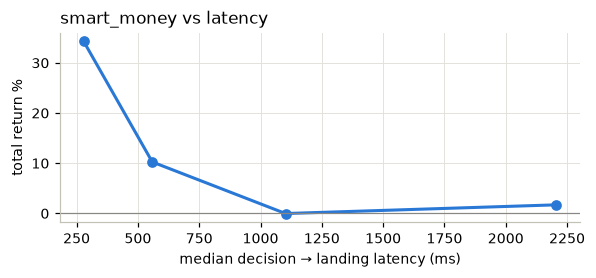

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.plot(lat["p50_latency_ms"], 100 * lat["total_return"], "o-", color=BLUE, lw=2)
ax.axhline(0, color=GRAY, lw=0.8); ax.set_xlabel("median decision → landing latency (ms)"); ax.set_ylabel("total return %")
ax.set_title("smart_money vs latency", loc="left"); plt.tight_layout(); plt.show()

## The report
Every CLI backtest writes this automatically; here we build one by hand.

In [8]:
import tempfile
from pumpfun_hft.analytics.montecarlo import trade_monte_carlo
mc = trade_monte_carlo(r.trades, r.initial_capital_sol, r.metrics["span_days"], settings.montecarlo, r.metrics["avg_latency_ms"], 2000)
out = ReportGenerator(r, mc).generate(tempfile.mkdtemp(), ["html", "json", "csv"])
print(out["html"]); print("P(loss) under resampling + cost stress:", round(mc.prob_loss, 3))

/tmp/tmplnvhztk3/report.html
P(loss) under resampling + cost stress: 0.454
